In [1]:
!pip install qiskit qiskit-aer matplotlib numpy pandas ipywidgets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.7 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Dict, Tuple, List
import string
import base64
from IPython.display import display, HTML, Markdown
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

In [3]:
class QuantumRandomGenerator:
    """Quantum Random Number Generator using Hadamard gates."""

    def __init__(self, num_qubits: int = 3):
        if not 1 <= num_qubits <= 10:
            raise ValueError("Number of qubits must be between 1 and 10")

        self.num_qubits = num_qubits
        self.max_value = 2 ** num_qubits - 1
        self.simulator = AerSimulator()

    def build_circuit(self, measure: bool = True) -> QuantumCircuit:
        """Build quantum circuit with Hadamard gates."""
        if measure:
            qc = QuantumCircuit(self.num_qubits, self.num_qubits)
        else:
            qc = QuantumCircuit(self.num_qubits)

        for i in range(self.num_qubits):
            qc.h(i)

        if measure:
            qc.measure(range(self.num_qubits), range(self.num_qubits))

        return qc

    def get_statevector(self, randomize: bool = True) -> Statevector:
        """Get a statevector for Bloch sphere visualization."""
        qc = QuantumCircuit(self.num_qubits)

        for i in range(self.num_qubits):
            if randomize:
                theta = np.random.uniform(0, 2 * np.pi)
                phi = np.random.uniform(0, 2 * np.pi)
                qc.rx(theta, i)
                qc.ry(phi, i)
            else:
                qc.h(i)

        return Statevector.from_instruction(qc)

    def generate_random_number(self) -> Tuple[str, int]:
        """Generate a single random number."""
        qc = self.build_circuit()
        compiled_circuit = transpile(qc, self.simulator)
        job = self.simulator.run(compiled_circuit, shots=1)
        result = job.result()
        counts = result.get_counts()

        binary_string = list(counts.keys())[0]
        decimal_value = int(binary_string, 2)

        return binary_string, decimal_value

    def run_qrng(self, shots: int = 1024) -> Dict[str, int]:
        """Run QRNG multiple times to collect distribution."""
        qc = self.build_circuit()
        compiled_circuit = transpile(qc, self.simulator)
        job = self.simulator.run(compiled_circuit, shots=shots)
        result = job.result()

        return result.get_counts()

    def analyze_distribution(self, counts: Dict[str, int], shots: int) -> Dict[str, float]:
        """Analyze randomness of the distribution."""
        num_outcomes = 2 ** self.num_qubits
        expected_count = shots / num_outcomes

        frequencies = list(counts.values())

        deviations = [(count - expected_count) ** 2 for count in frequencies]
        std_dev = np.sqrt(np.mean(deviations))

        chi_squared = sum((count - expected_count) ** 2 / expected_count
                         for count in frequencies)

        return {
            'expected_outcomes': num_outcomes,
            'actual_outcomes': len(counts),
            'expected_count_per_outcome': expected_count,
            'mean_count': np.mean(frequencies),
            'std_deviation': std_dev,
            'chi_squared': chi_squared,
            'min_count': min(frequencies),
            'max_count': max(frequencies)
        }


In [12]:
class QuantumColorGenerator:
    """Generate random colors using quantum measurements."""

    def __init__(self):
        self.qrng = QuantumRandomGenerator(num_qubits=8)

    def generate_color(self) -> Tuple[str, Tuple[int, int, int]]:
        """Generate a random RGB color."""
        qc = QuantumCircuit(8, 8)

        for i in range(8):
            qc.h(i)
        qc.measure(range(8), range(8))

        compiled_circuit = transpile(qc, self.qrng.simulator)

        rgb = []
        for _ in range(3):
            job = self.qrng.simulator.run(compiled_circuit, shots=1)
            result = job.result()
            counts = result.get_counts()
            binary = list(counts.keys())[0]
            value = int(binary, 2)
            rgb.append(value)

        r, g, b = rgb
        hex_color = f"#{r:02x}{g:02x}{b:02x}"

        return hex_color, (r, g, b)

    def generate_palette(self, num_colors: int = 5) -> List[Tuple[str, Tuple[int, int, int]]]:
        """Generate a color palette."""
        return [self.generate_color() for _ in range(num_colors)]


In [13]:
class QuantumPasswordGenerator:
    """Generate secure passwords using quantum randomness."""

    def __init__(self):
        self.qrng = QuantumRandomGenerator(num_qubits=8)

    def generate_password(self, length: int = 16, use_upper: bool = True,
                         use_lower: bool = True, use_digits: bool = True,
                         use_special: bool = True) -> str:
        """Generate a random password."""
        charset = ""
        if use_upper:
            charset += string.ascii_uppercase
        if use_lower:
            charset += string.ascii_lowercase
        if use_digits:
            charset += string.digits
        if use_special:
            charset += "!@#$%^&*()_+-=[]{}|;:,.<>?"

        if not charset:
            charset = string.ascii_letters + string.digits

        password = []
        qc = QuantumCircuit(8, 8)
        for i in range(8):
            qc.h(i)
        qc.measure(range(8), range(8))
        compiled_circuit = transpile(qc, self.qrng.simulator)

        for _ in range(length):
            job = self.qrng.simulator.run(compiled_circuit, shots=1)
            result = job.result()
            counts = result.get_counts()
            binary = list(counts.keys())[0]
            random_value = int(binary, 2)
            char_index = random_value % len(charset)
            password.append(charset[char_index])

        return ''.join(password)


In [14]:
class QuantumCryptoKeyGenerator:
    """Generate cryptographic keys using quantum randomness."""

    def __init__(self):
        self.qrng = QuantumRandomGenerator(num_qubits=8)

    def generate_symmetric_key(self, bits: int = 256) -> Tuple[str, str]:
        """Generate a symmetric encryption key."""
        num_bytes = bits // 8
        key_bytes = []

        qc = QuantumCircuit(8, 8)
        for i in range(8):
            qc.h(i)
        qc.measure(range(8), range(8))
        compiled_circuit = transpile(qc, self.qrng.simulator)

        for _ in range(num_bytes):
            job = self.qrng.simulator.run(compiled_circuit, shots=1)
            result = job.result()
            counts = result.get_counts()
            binary = list(counts.keys())[0]
            byte_value = int(binary, 2)
            key_bytes.append(byte_value)

        key_hex = ''.join([f"{b:02x}" for b in key_bytes])
        key_base64 = base64.b64encode(bytes(key_bytes)).decode('utf-8')

        return key_hex, key_base64

    def generate_api_key(self, length: int = 32) -> str:
        """Generate API key."""
        charset = string.ascii_letters + string.digits
        api_key = []

        qc = QuantumCircuit(8, 8)
        for i in range(8):
            qc.h(i)
        qc.measure(range(8), range(8))
        compiled_circuit = transpile(qc, self.qrng.simulator)

        for _ in range(length):
            job = self.qrng.simulator.run(compiled_circuit, shots=1)
            result = job.result()
            counts = result.get_counts()
            binary = list(counts.keys())[0]
            random_value = int(binary, 2)
            char_index = random_value % len(charset)
            api_key.append(charset[char_index])

        return ''.join(api_key)


In [15]:
def display_color_box(hex_color, rgb):
    """Display a colored box."""
    html = f"""
    <div style='background-color: {hex_color}; padding: 60px;
    border-radius: 10px; text-align: center;
    color: {"white" if sum(rgb) < 384 else "black"};
    font-size: 24px; font-weight: bold; border: 2px solid #ddd;
    margin: 10px 0;'>
        {hex_color.upper()}<br>
        RGB: ({rgb[0]}, {rgb[1]}, {rgb[2]})
    </div>
    """
    display(HTML(html))

In [16]:
def display_palette(palette):
    """Display a color palette."""
    html = "<div style='display: flex; gap: 10px; margin: 10px 0;'>"
    for hex_color, rgb in palette:
        html += f"""
        <div style='background-color: {hex_color}; padding: 40px;
        border-radius: 8px; flex: 1; border: 1px solid #ddd;
        text-align: center; font-size: 12px;'>
            {hex_color.upper()}
        </div>
        """
    html += "</div>"
    display(HTML(html))


In [17]:
print("🎲 QUANTUM RANDOM NUMBER GENERATOR\n")
# Interactive widget
@interact(num_qubits=widgets.IntSlider(min=1, max=10, value=3, description='Qubits:'))
def generate_single(num_qubits):
    qrng = QuantumRandomGenerator(num_qubits=num_qubits)
    binary, decimal = qrng.generate_random_number()

    print(f"\n🌌 Quantum Random Number Generated!")
    print(f"📊 Range: 0 to {2**num_qubits - 1}")
    print(f"🔢 Binary:  {binary}")
    print(f"🔢 Decimal: {decimal}")

    # Show circuit
    circuit = qrng.build_circuit()
    print(f"\n⚛️  Quantum Circuit:")
    print(circuit.draw(output='text'))

🎲 QUANTUM RANDOM NUMBER GENERATOR



interactive(children=(IntSlider(value=3, description='Qubits:', max=10, min=1), Output()), _dom_classes=('widg…

In [18]:
class QuantumRandomGenerator:
    """Quantum Random Number Generator using Hadamard gates."""

    def __init__(self, num_qubits: int = 3):
        if not 1 <= num_qubits <= 10:
            raise ValueError("Number of qubits must be between 1 and 10")

        self.num_qubits = num_qubits
        self.max_value = 2 ** num_qubits - 1
        self.simulator = AerSimulator()

    def build_circuit(self, measure: bool = True) -> QuantumCircuit:
        """Build quantum circuit with Hadamard gates."""
        if measure:
            qc = QuantumCircuit(self.num_qubits, self.num_qubits)
        else:
            qc = QuantumCircuit(self.num_qubits)

        # Apply Hadamard gate to create superposition
        for i in range(self.num_qubits):
            qc.h(i)

        # Measure all qubits if requested
        if measure:
            qc.measure(range(self.num_qubits), range(self.num_qubits))

        return qc

    def get_statevector(self, randomize: bool = True) -> Statevector:
        """Get a statevector for Bloch sphere visualization.

        If randomize=True, apply random single-qubit rotations to show varied states.
        """
        qc = QuantumCircuit(self.num_qubits)

        for i in range(self.num_qubits):
            if randomize:
                # Apply random single-qubit rotations to diversify the states
                theta = np.random.uniform(0, 2 * np.pi)
                phi = np.random.uniform(0, 2 * np.pi)
                qc.rx(theta, i)
                qc.ry(phi, i)
            else:
                # Default Hadamard state
                qc.h(i)

        return Statevector.from_instruction(qc)


    def generate_random_number(self) -> Tuple[str, int]:
        """Generate a single random number."""
        qc = self.build_circuit()
        compiled_circuit = transpile(qc, self.simulator)
        job = self.simulator.run(compiled_circuit, shots=1)
        result = job.result()
        counts = result.get_counts()

        binary_string = list(counts.keys())[0]
        decimal_value = int(binary_string, 2)

        return binary_string, decimal_value

    def run_qrng(self, shots: int = 1024) -> Dict[str, int]:
        """Run QRNG multiple times to collect distribution."""
        qc = self.build_circuit()
        compiled_circuit = transpile(qc, self.simulator)
        job = self.simulator.run(compiled_circuit, shots=shots)
        result = job.result()

        return result.get_counts()

    def analyze_distribution(self, counts: Dict[str, int], shots: int) -> Dict[str, float]:
        """Analyze randomness of the distribution."""
        num_outcomes = 2 ** self.num_qubits
        expected_count = shots / num_outcomes

        # Handle cases where some outcomes might not appear in counts
        all_outcomes = [bin(i)[2:].zfill(self.num_qubits) for i in range(num_outcomes)]
        full_counts = {outcome: counts.get(outcome, 0) for outcome in all_outcomes}

        frequencies = list(full_counts.values())

        deviations = [(count - expected_count) ** 2 for count in frequencies]
        std_dev = np.sqrt(np.mean(deviations))

        # Avoid division by zero if expected_count is 0
        chi_squared = sum((count - expected_count) ** 2 / expected_count
                         for count in frequencies) if expected_count > 0 else float('inf')


        return {
            'expected_outcomes': num_outcomes,
            'actual_outcomes': len(counts),
            'expected_count_per_outcome': expected_count,
            'mean_count': np.mean(frequencies),
            'std_deviation': std_dev,
            'chi_squared': chi_squared,
            'min_count': min(frequencies),
            'max_count': max(frequencies)
        }

    def generate_random_bytes(self, num_bytes: int) -> bytes:
        """Generate random bytes using quantum measurements."""
        random_bytes = []
        # Use a circuit that measures each qubit individually to get byte values
        qc = self.build_circuit() # build_circuit with measure=True by default

        compiled_circuit = transpile(qc, self.simulator)

        for _ in range(num_bytes):
            # Run the circuit to get a measurement result (a binary string)
            job = self.simulator.run(compiled_circuit, shots=1)
            result = job.result()
            counts = result.get_counts()
            binary_string = list(counts.keys())[0]

            # Convert the first 8 bits of the binary string to a byte
            # Ensure the binary string is at least 8 bits long
            byte_value = int(binary_string[:8], 2) if len(binary_string) >= 8 else int(binary_string.ljust(8, '0'), 2)
            random_bytes.append(byte_value)

        return bytes(random_bytes)

In [20]:
print("📊 DISTRIBUTION ANALYSIS\n")

num_qubits = 3  # Change this value
shots = 1024    # Change this value

qrng = QuantumRandomGenerator(num_qubits=num_qubits)
counts = qrng.run_qrng(shots=shots)
stats = qrng.analyze_distribution(counts, shots)

# Plot histogram
fig = plot_histogram(counts, figsize=(12, 6),
                     title=f'Distribution of {shots} Quantum Measurements ({num_qubits} qubits)')
plt.tight_layout()
plt.show()

📊 DISTRIBUTION ANALYSIS



<Figure size 640x480 with 0 Axes>

In [21]:
# Display statistics
print("\n📈 STATISTICAL METRICS:")
print(f"Expected outcomes: {stats['expected_outcomes']}")
print(f"Actual outcomes: {stats['actual_outcomes']}")
print(f"Expected count per outcome: {stats['expected_count_per_outcome']:.1f}")
print(f"Mean count: {stats['mean_count']:.1f}")
print(f"Standard deviation: {stats['std_deviation']:.2f}")
print(f"Chi-squared: {stats['chi_squared']:.2f}")
print(f"Min count: {stats['min_count']}")
print(f"Max count: {stats['max_count']}")


📈 STATISTICAL METRICS:
Expected outcomes: 8
Actual outcomes: 8
Expected count per outcome: 128.0
Mean count: 128.0
Standard deviation: 11.35
Chi-squared: 8.05
Min count: 115
Max count: 151


In [22]:
# Randomness assessment
expected = stats['expected_count_per_outcome']
relative_std = (stats['std_deviation'] / expected) * 100
print(f"\n✅ Relative Standard Deviation: {relative_std:.1f}%")

if relative_std < 10:
    print("🌟 Excellent uniformity! The distribution shows excellent quantum randomness.")
elif relative_std < 20:
    print("👍 Good uniformity! The distribution shows good quantum randomness.")
else:
    print("⚠️  Fair uniformity. Consider increasing shots for better statistics.")



✅ Relative Standard Deviation: 8.9%
🌟 Excellent uniformity! The distribution shows excellent quantum randomness.


In [23]:
# Create data table
sorted_counts = dict(sorted(counts.items()))
data = []
for binary, count in sorted_counts.items():
    decimal = int(binary, 2)
    probability = (count / shots) * 100
    data.append({
        'Binary': binary,
        'Decimal': decimal,
        'Count': count,
        'Probability (%)': f"{probability:.2f}%"
    })

df = pd.DataFrame(data)
print("\n📋 PROBABILITY TABLE:")
display(df)


📋 PROBABILITY TABLE:


,Binary,Decimal,Count,Probability (%)
0,000,0,120,11.72%
1,001,1,115,11.23%
2,010,2,127,12.40%
3,011,3,151,14.75%
4,100,4,127,12.40%
5,101,5,139,13.57%
6,110,6,129,12.60%
7,111,7,116,11.33%


In [24]:
print("🎨 QUANTUM COLOR GENERATOR\n")

color_gen = QuantumColorGenerator()

# Generate single color
print("Generating single quantum color...")
hex_color, rgb = color_gen.generate_color()
display_color_box(hex_color, rgb)

print(f"\nCSS: color: {hex_color};")
print(f"RGB: ({rgb[0]}, {rgb[1]}, {rgb[2]})")

# Generate palette
print("\n🎨 Generating Quantum Color Palette...")
palette = color_gen.generate_palette(num_colors=5)
display_palette(palette)

print("\nPalette colors:")
for i, (hex_color, rgb) in enumerate(palette, 1):
    print(f"{i}. {hex_color.upper()} - RGB{rgb}")


🎨 QUANTUM COLOR GENERATOR

Generating single quantum color...



CSS: color: #1320d4;
RGB: (19, 32, 212)

🎨 Generating Quantum Color Palette...



Palette colors:
1. #05798C - RGB(5, 121, 140)
2. #9EA2E7 - RGB(158, 162, 231)
3. #E6D5A4 - RGB(230, 213, 164)
4. #F6B8FC - RGB(246, 184, 252)
5. #101683 - RGB(16, 22, 131)


In [25]:
print("🔐 QUANTUM PASSWORD GENERATOR\n")

pwd_gen = QuantumPasswordGenerator()

# Generate passwords with different configurations
configs = [
    (16, True, True, True, True, "Strong (All character types)"),
    (20, True, True, True, False, "No special characters"),
    (12, False, True, True, False, "Lowercase + digits only"),
]

for length, upper, lower, digits, special, description in configs:
    password = pwd_gen.generate_password(
        length=length,
        use_upper=upper,
        use_lower=lower,
        use_digits=digits,
        use_special=special
    )
    print(f"\n{description}:")
    print(f"  {password}")

print("\n⚠️  Security Tips:")
print("  • Never share passwords")
print("  • Use unique passwords for each account")
print("  • Store passwords in a password manager")
print("  • Enable 2FA when available")


🔐 QUANTUM PASSWORD GENERATOR


Strong (All character types):
  W4%W%wCNKSW-&?G,

No special characters:
  3Gm807IWzJK7Tii5xpQJ

Lowercase + digits only:
  roaq7xeoubnh

⚠️  Security Tips:
  • Never share passwords
  • Use unique passwords for each account
  • Store passwords in a password manager
  • Enable 2FA when available


In [26]:
print("🔑 QUANTUM CRYPTOGRAPHIC KEY GENERATOR\n")

crypto_gen = QuantumCryptoKeyGenerator()

# Generate different key types
print("1️⃣  AES-256 Symmetric Key:")
key_hex, key_base64 = crypto_gen.generate_symmetric_key(256)
print(f"   Hex: {key_hex[:64]}...")
print(f"   Base64: {key_base64[:32]}...")

print("\n2️⃣  API Key:")
api_key = crypto_gen.generate_api_key(32)
print(f"   {api_key}")

print("\n3️⃣  AES-128 Key (for demonstration):")
key_hex_128, _ = crypto_gen.generate_symmetric_key(128)
print(f"   {key_hex_128}")

print("\n🔒 Security Best Practices:")
print("  • Store keys in environment variables or key management systems")
print("  • Never hardcode keys in source code")
print("  • Use different keys for dev, staging, and production")
print("  • Rotate keys regularly")


🔑 QUANTUM CRYPTOGRAPHIC KEY GENERATOR

1️⃣  AES-256 Symmetric Key:
   Hex: ebbc1a33d40f55272154536c6c2447260bf29d7f4b09503842d53246f42cc695...
   Base64: 67waM9QPVSchVFNsbCRHJgvynX9LCVA4...

2️⃣  API Key:
   I3CTLhfMIptAsmClxSrG2wXa4GgU59ir

3️⃣  AES-128 Key (for demonstration):
   fcb84a487a7184fa367f284bfa7ba8d0

🔒 Security Best Practices:
  • Store keys in environment variables or key management systems
  • Never hardcode keys in source code
  • Use different keys for dev, staging, and production
  • Rotate keys regularly


In [27]:
print("🎮 INTERACTIVE QUANTUM RANDOM NUMBER GENERATOR\n")

@interact(
    num_qubits=widgets.IntSlider(min=1, max=8, value=3, description='Qubits:'),
    num_samples=widgets.IntSlider(min=1, max=20, value=5, description='Samples:')
)
def interactive_generator(num_qubits, num_samples):
    qrng = QuantumRandomGenerator(num_qubits=num_qubits)

    print(f"\n🎲 Generating {num_samples} random numbers using {num_qubits} qubits")
    print(f"📊 Range: 0 to {2**num_qubits - 1}\n")

    results = []
    for i in range(num_samples):
        binary, decimal = qrng.generate_random_number()
        results.append({'#': i+1, 'Binary': binary, 'Decimal': decimal})

    df = pd.DataFrame(results)
    display(df)

    # Simple statistics
    decimals = [r['Decimal'] for r in results]
    print(f"\n📈 Statistics:")
    print(f"   Mean: {np.mean(decimals):.2f}")
    print(f"   Min: {min(decimals)}")
    print(f"   Max: {max(decimals)}")

🎮 INTERACTIVE QUANTUM RANDOM NUMBER GENERATOR



interactive(children=(IntSlider(value=3, description='Qubits:', max=8, min=1), IntSlider(value=5, description=…

⚡ BATCH QUANTUM OPERATIONS

Generating 100 quantum random numbers (3 qubits)...


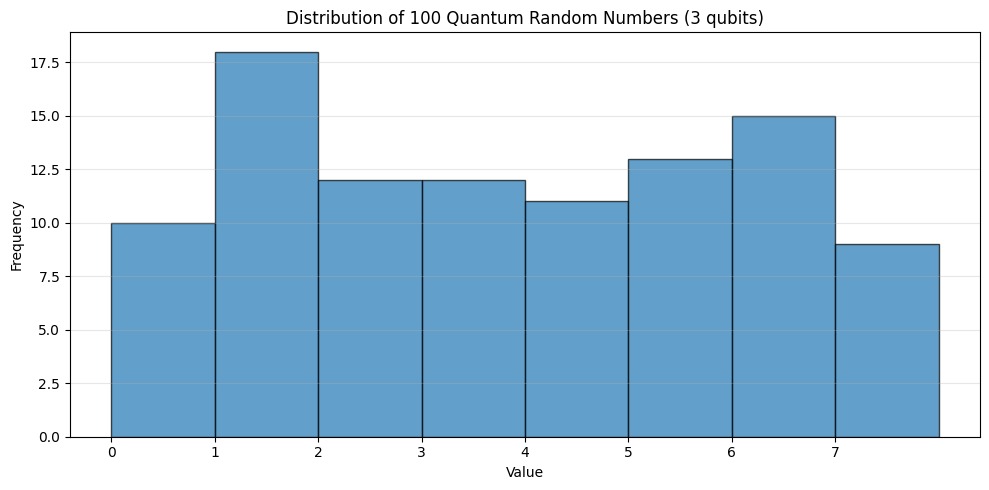


📊 Generated 100 quantum random numbers
   Mean: 3.40
   Std Dev: 2.24

✅ All cells executed successfully!
🌌 Quantum Random Number Generator is ready to use!


In [28]:
print("⚡ BATCH QUANTUM OPERATIONS\n")

def batch_generate(num_qubits, count, operation='numbers'):
    """Generate multiple quantum random items."""
    if operation == 'numbers':
        qrng = QuantumRandomGenerator(num_qubits=num_qubits)
        results = []
        for _ in range(count):
            binary, decimal = qrng.generate_random_number()
            results.append(decimal)
        return results

    elif operation == 'colors':
        color_gen = QuantumColorGenerator()
        return color_gen.generate_palette(count)

    elif operation == 'passwords':
        pwd_gen = QuantumPasswordGenerator()
        return [pwd_gen.generate_password(16) for _ in range(count)]

# Example: Generate 100 random numbers and plot distribution
print("Generating 100 quantum random numbers (3 qubits)...")
numbers = batch_generate(3, 100, 'numbers')

plt.figure(figsize=(10, 5))
plt.hist(numbers, bins=range(9), alpha=0.7, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of 100 Quantum Random Numbers (3 qubits)')
plt.xticks(range(8))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Generated {len(numbers)} quantum random numbers")
print(f"   Mean: {np.mean(numbers):.2f}")
print(f"   Std Dev: {np.std(numbers):.2f}")

print("\n✅ All cells executed successfully!")
print("🌌 Quantum Random Number Generator is ready to use!")